In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
clientes = pd.read_csv('data/clientes.csv')
contratos_ativos = pd.read_csv('data/contratos_ativos.csv')
interacoes = pd.read_csv('data/interacoes.csv')
produtos = pd.read_csv('data/produtos.csv')

# Análise Exploratória de Dados (EDA)

Neste notebook, vamos explorar os dados dos clientes, contratos, interações e produtos para entender distribuição, valores ausentes e métricas principais.

In [74]:
contratos_ativos.status.unique()

array(['ativo', 'cancelado', 'vencido'], dtype=object)

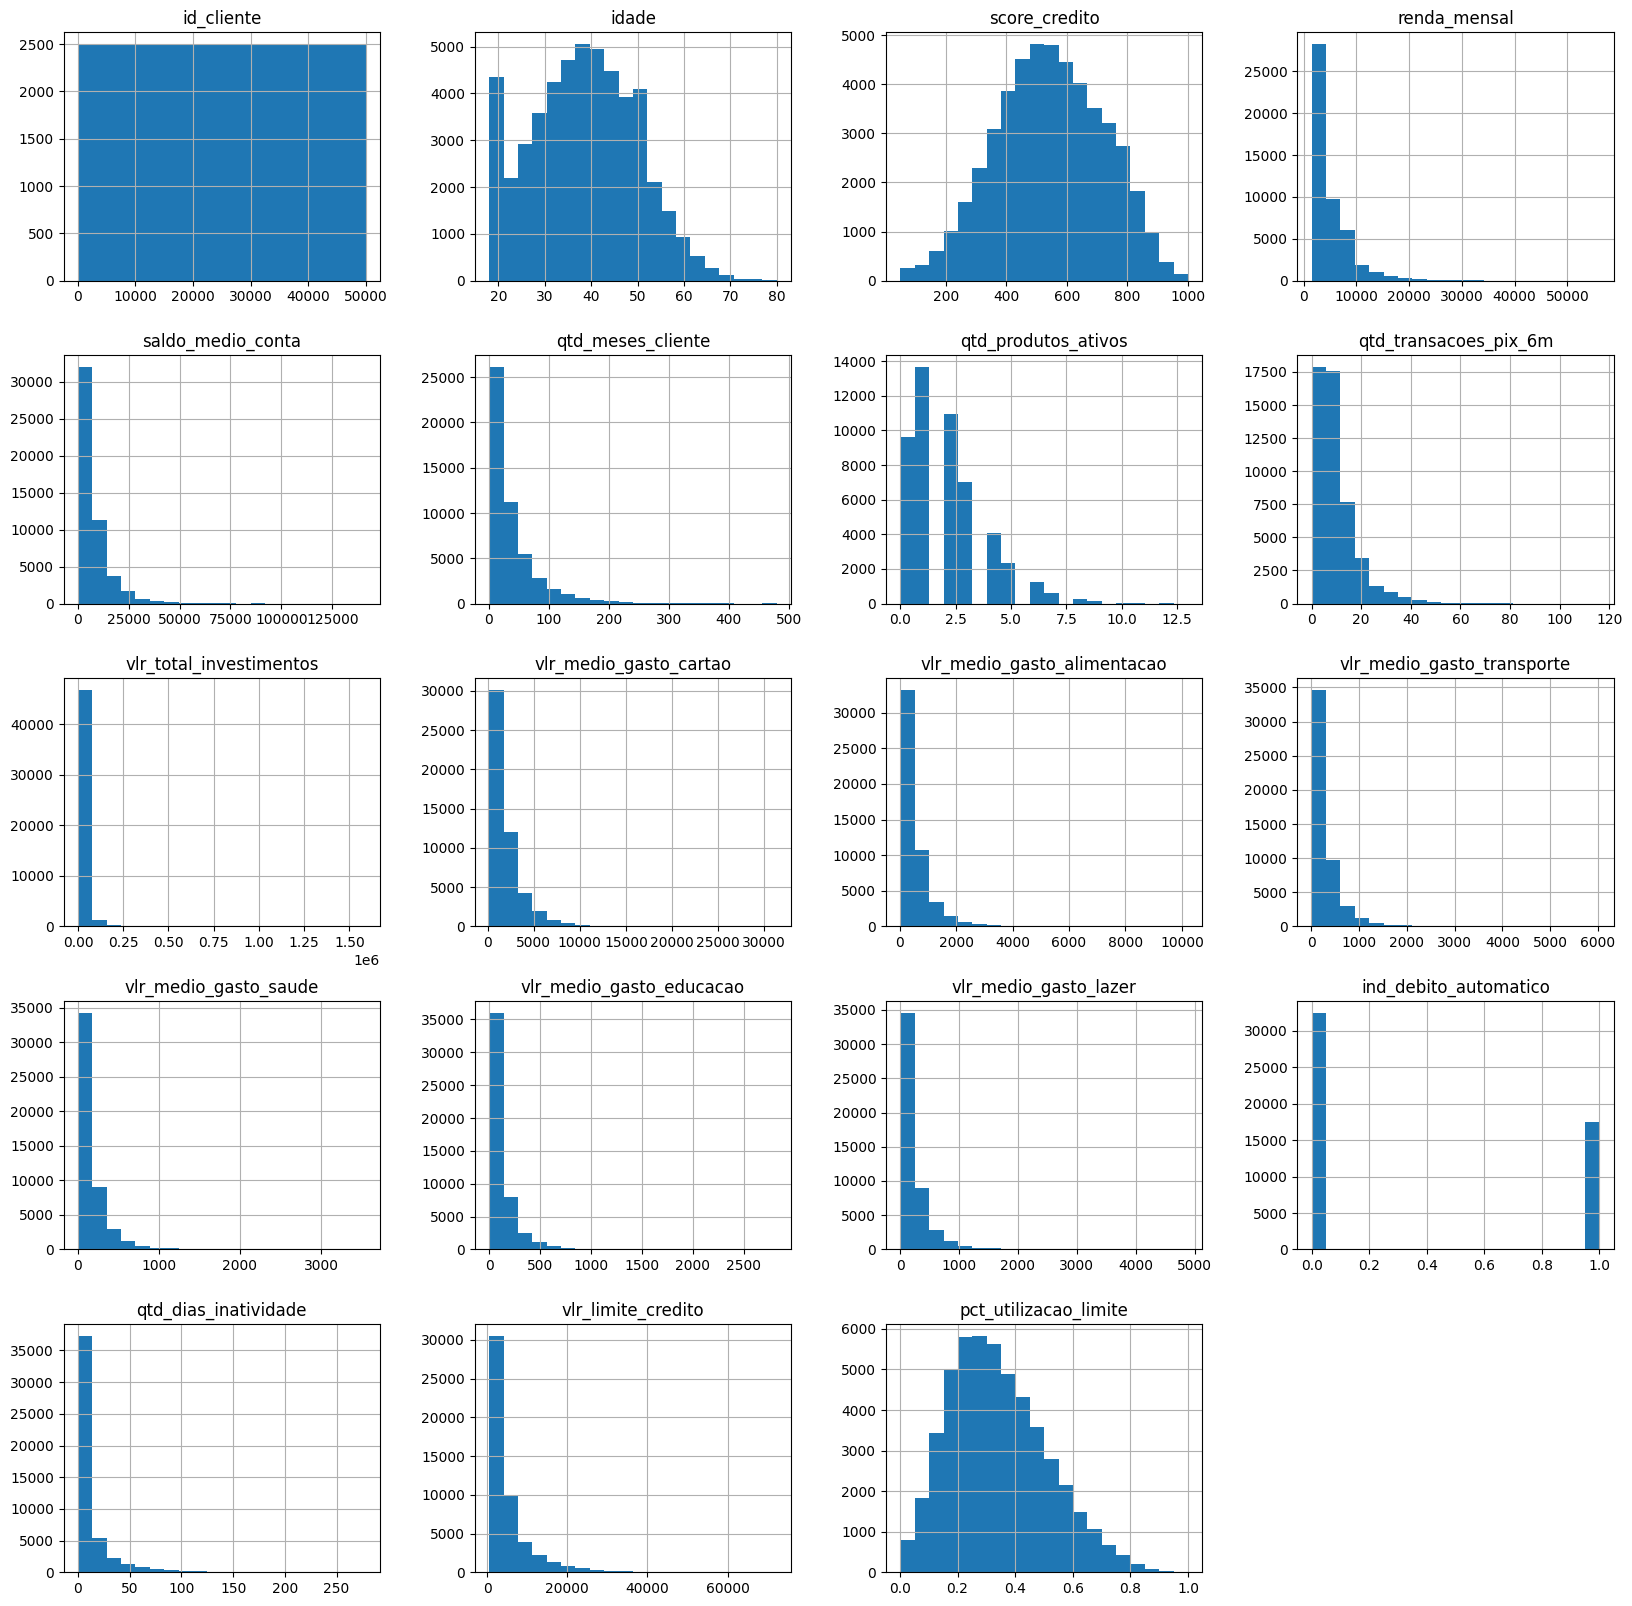

In [15]:
clientes.hist(bins=20, figsize=(20, 20))
plt.show()

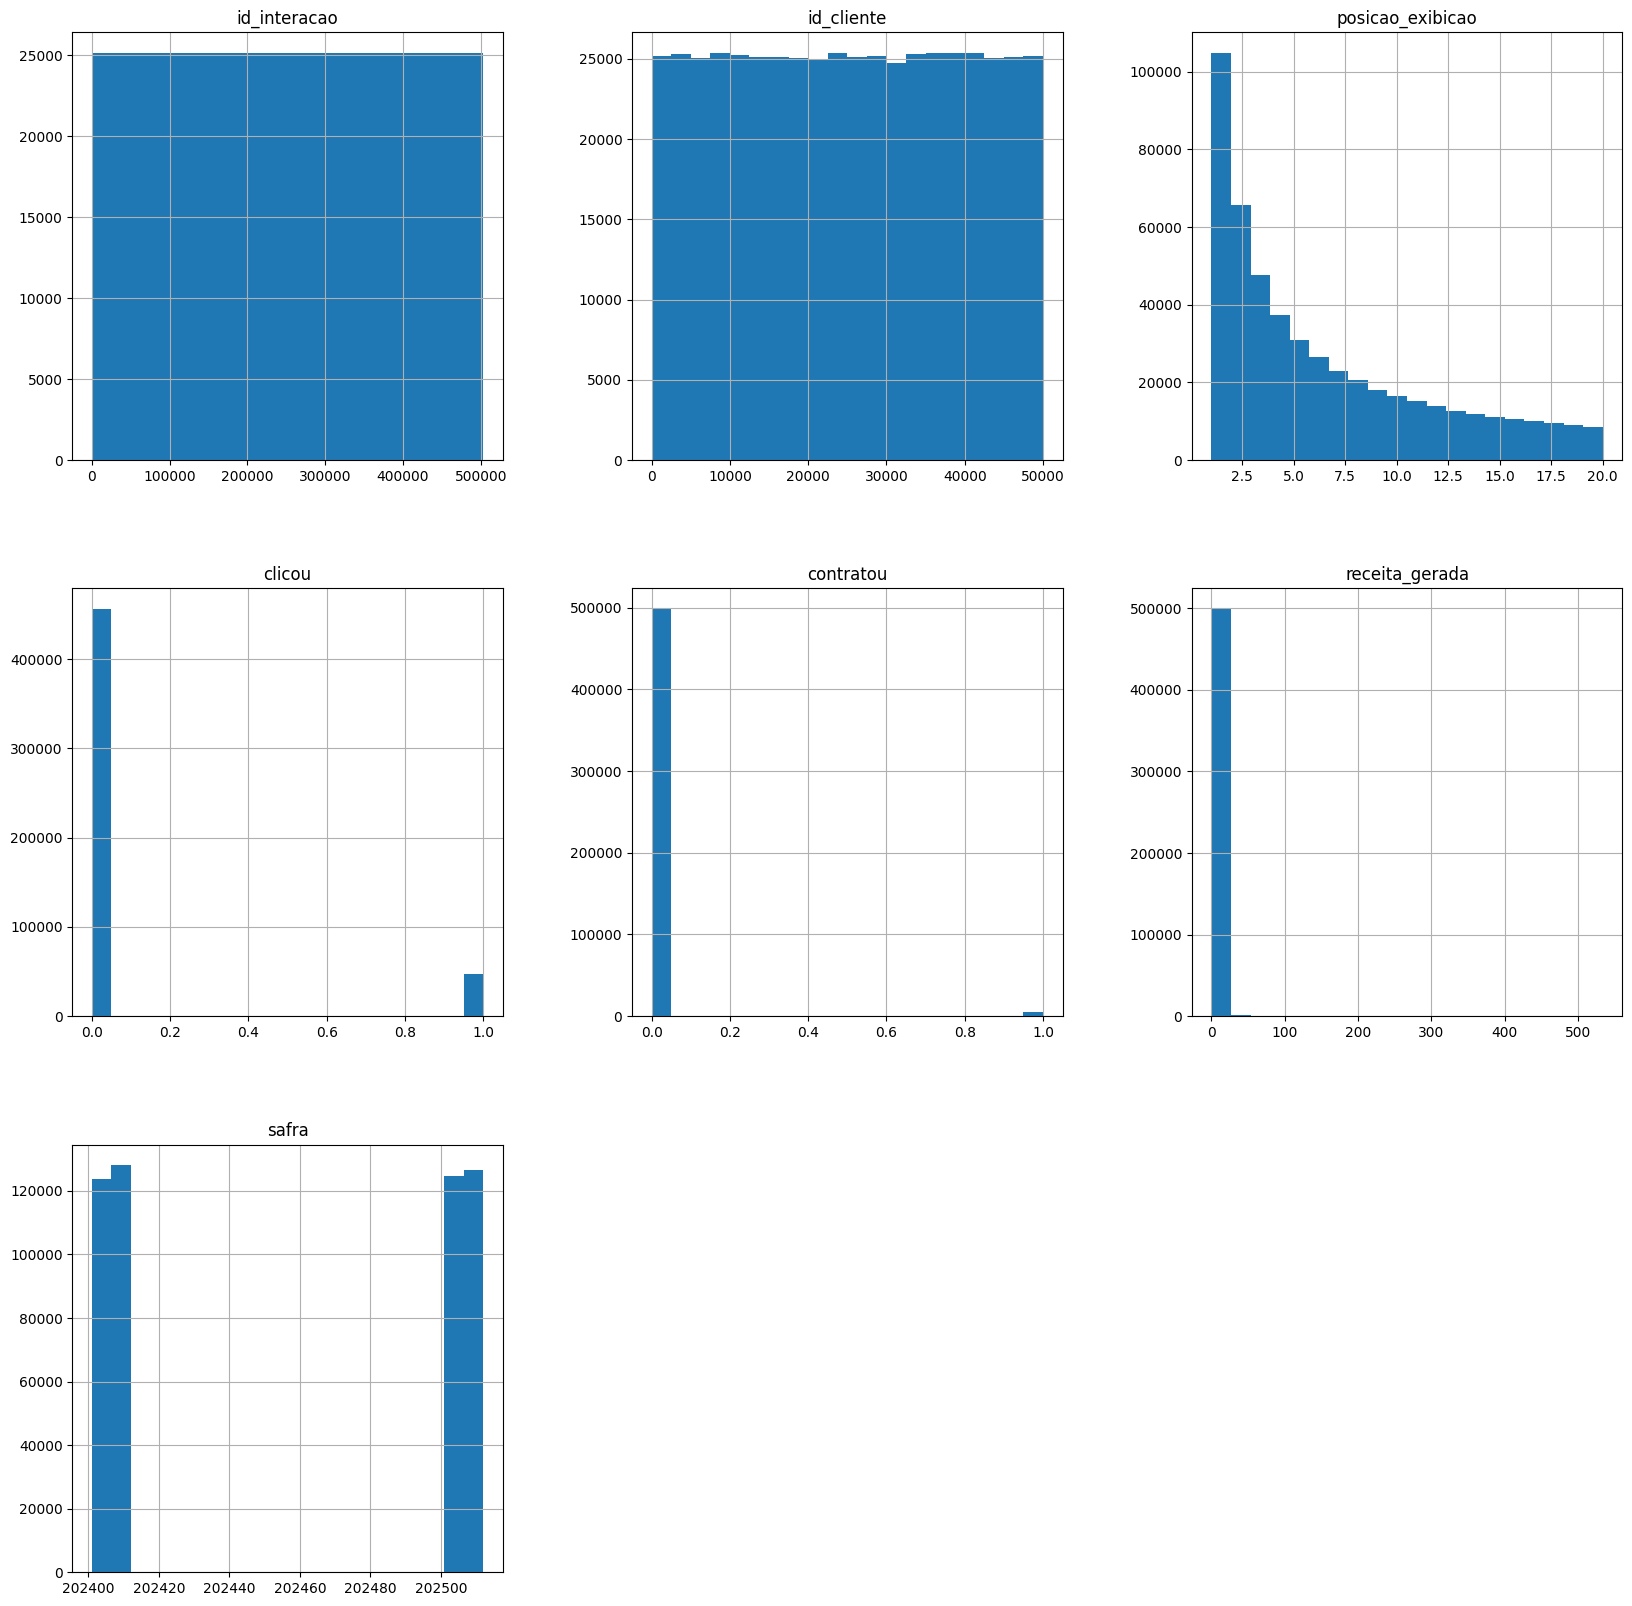

In [16]:
interacoes.hist(bins=20, figsize=(20, 20))
plt.show()

In [23]:
interacoes[(interacoes.clicou==1) & (interacoes.contratou==1)].sort_values('produto').posicao_exibicao.value_counts()

posicao_exibicao
1     2421
2      969
3      514
4      308
5      221
6       29
7       21
8       13
9       11
10       7
11       2
12       1
20       1
19       1
Name: count, dtype: int64

In [72]:
interacoes.safra.max()

np.int64(202512)

In [25]:
produtos.head()

,produto,categoria,receita_media,custo_aquisicao,margem,publico_alvo
0,cartao_platinum,cartao,45.0,8.0,0.82,Clientes com volume medio-alto de gastos mensa...
1,cartao_black,cartao,120.0,18.0,0.85,Clientes ultra-premium com alto volume de gast...
2,credito_pessoal,credito,210.0,35.0,0.83,Clientes com necessidade de credito e bom score
3,credito_consignado,credito,180.0,28.0,0.84,Clientes com renda comprovada via folha de pag...
4,cheque_especial,credito,90.0,12.0,0.87,Clientes que precisam de credito emergencial d...


In [70]:
clientes.columns

Index(['id_cliente', 'idade', 'genero', 'uf', 'segmento', 'score_credito',
       'renda_mensal', 'saldo_medio_conta', 'qtd_meses_cliente',
       'qtd_produtos_ativos', 'qtd_transacoes_pix_6m',
       'vlr_total_investimentos', 'vlr_medio_gasto_cartao',
       'vlr_medio_gasto_alimentacao', 'vlr_medio_gasto_transporte',
       'vlr_medio_gasto_saude', 'vlr_medio_gasto_educacao',
       'vlr_medio_gasto_lazer', 'ind_debito_automatico',
       'qtd_dias_inatividade', 'vlr_limite_credito', 'pct_utilizacao_limite',
       'canal_preferencial'],
      dtype='object')

In [26]:
clientes.head()

,id_cliente,idade,genero,uf,segmento,score_credito,renda_mensal,saldo_medio_conta,qtd_meses_cliente,qtd_produtos_ativos,...,vlr_medio_gasto_alimentacao,vlr_medio_gasto_transporte,vlr_medio_gasto_saude,vlr_medio_gasto_educacao,vlr_medio_gasto_lazer,ind_debito_automatico,qtd_dias_inatividade,vlr_limite_credito,pct_utilizacao_limite,canal_preferencial
0,1,34,F,PR,basico,617.21,1500.00,2981.16,17,0,...,97.96,139.06,38.89,35.88,114.53,1,12.0,725.95,0.2062,agencia
1,2,58,F,SP,premium,700.98,16620.77,41901.11,21,8,...,705.43,679.74,487.83,147.66,415.77,0,6.0,14116.66,0.1795,web
2,3,46,F,AM,intermediario,696.96,4202.55,916.78,57,2,...,795.14,239.72,69.56,245.75,357.10,1,8.0,4414.47,0.4499,app
3,4,31,M,RS,intermediario,611.78,5969.66,10472.53,58,0,...,704.23,582.83,182.11,21.38,520.29,0,3.0,4992.60,0.3728,app
4,5,56,F,MG,basico,233.49,1816.86,1909.79,32,0,...,49.23,36.48,26.78,9.68,19.63,0,0.0,2139.83,0.5960,app


In [27]:
interacoes.head()

,id_interacao,id_cliente,produto,posicao_exibicao,canal,clicou,contratou,receita_gerada,timestamp,safra
0,1,45719,previdencia,1,push_notification,0,0,0.0,2024-01-22 20:36:00,202401
1,2,46225,conta_digital_plus,1,app_home,0,0,0.0,2024-01-24 14:49:00,202401
2,3,38294,cartao_platinum,5,app_home,0,0,0.0,2024-01-13 10:48:00,202401
3,4,23592,investimento_lci_lca,16,email,0,0,0.0,2024-01-14 14:42:00,202401
4,5,24185,credito_pessoal,17,app_home,0,0,0.0,2024-01-15 11:00:00,202401


In [35]:
contratos_ativos['data_contratacao'] = pd.to_datetime(contratos_ativos['data_contratacao'])

In [36]:
contratos_ativos.dtypes

id_cliente                    int64
produto                      object
data_contratacao     datetime64[ns]
status                       object
canal_contratacao            object
dtype: object

In [38]:
contratos_ativos['ano_mes'] = contratos_ativos['data_contratacao'].dt.to_period('M')

In [39]:
contratos_ativos.head()

,id_cliente,produto,data_contratacao,status,canal_contratacao,ano_mes
0,1,previdencia,2025-10-23,ativo,app,2025-10
1,4,seguro_residencial,2025-10-26,cancelado,app,2025-10
2,4,conta_digital_plus,2025-03-25,ativo,app,2025-03
3,5,credito_consignado,2024-08-08,ativo,agencia,2024-08
4,5,cheque_especial,2025-09-04,ativo,app,2025-09


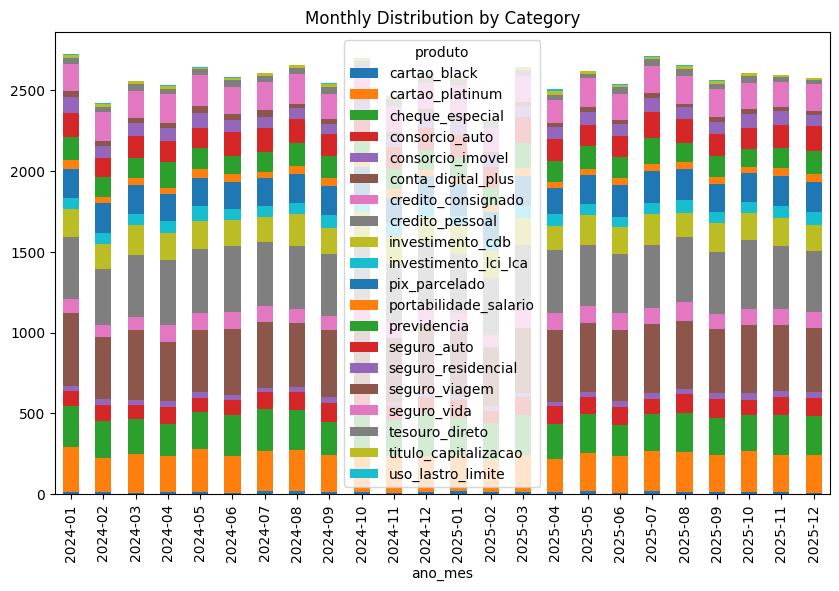

In [42]:
# Create a pivot table: Rows are Months, Columns are the categories to stack
monthly_data = contratos_ativos.groupby([contratos_ativos['ano_mes'], 'produto']).size().unstack()
# monthly_data = monthly_data.reindex(month_order)

# Plot
monthly_data.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Monthly Distribution by Category')
plt.show()

In [44]:
interacoes[interacoes.contratou==1]

,id_interacao,id_cliente,produto,posicao_exibicao,canal,clicou,contratou,receita_gerada,timestamp,safra
349,350,5423,cartao_platinum,4,app_busca,1,1,45.73,2024-01-13 16:05:00,202401
571,572,13606,conta_digital_plus,1,app_busca,1,1,31.42,2024-01-02 20:01:00,202401
657,658,17988,cartao_platinum,2,app_home,1,1,67.32,2024-01-28 11:33:00,202401
667,668,37169,investimento_cdb,1,app_busca,1,1,59.60,2024-01-13 09:01:00,202401
685,686,3217,conta_digital_plus,2,app_busca,1,1,18.55,2024-01-30 10:00:00,202401
...,...,...,...,...,...,...,...,...,...,...
502914,502915,7741,cheque_especial,1,app_home,1,1,83.95,2025-12-13 14:48:00,202512
502971,502972,22509,seguro_auto,3,app_busca,1,1,152.37,2025-12-24 08:54:00,202512
503088,503089,646,previdencia,2,app_busca,1,1,97.95,2025-12-31 10:22:00,202512
503091,503092,22752,previdencia,1,web_banking,1,1,184.29,2025-12-21 11:00:00,202512


In [49]:
contratos_ativos[contratos_ativos.id_cliente==38425]

,id_cliente,produto,data_contratacao,status,canal_contratacao,ano_mes
47562,38425,consorcio_auto,2024-02-14,ativo,telemarketing,2024-02


Achado: clientes aparecem na base de intercaoes como contratou, mas isso não reflete na base de contratos_ativos

In [50]:
contratos_ativos

,id_cliente,produto,data_contratacao,status,canal_contratacao,ano_mes
0,1,previdencia,2025-10-23,ativo,app,2025-10
1,4,seguro_residencial,2025-10-26,cancelado,app,2025-10
2,4,conta_digital_plus,2025-03-25,ativo,app,2025-03
3,5,credito_consignado,2024-08-08,ativo,agencia,2024-08
4,5,cheque_especial,2025-09-04,ativo,app,2025-09
...,...,...,...,...,...,...
61992,49998,cheque_especial,2024-09-18,ativo,agencia,2024-09
61993,50000,seguro_residencial,2024-12-07,ativo,web,2024-12
61994,50000,cartao_platinum,2024-05-01,cancelado,app,2024-05
61995,50000,investimento_cdb,2024-01-10,ativo,app,2024-01


1. Análise Exploratória dos Dados
- Distribuições das features dos clientes (por segmento, faixa etária, etc.)
- Análise do histórico de interações: taxa de clique e contratação por produto, por canal, por posição no carrossel
- Análise da distribuição de contratações por produto
- Análise de co-contratação: quais produtos são contratados juntos? Quais raramente coexistem?
- Análise temporal: há padrões sazonais? Tendências ao longo das safras?
- Tratamento de dados: missing values, outliers, features correlacionadas
- Feature engineering relevante

## Análise de co-contratação: quais produtos são contratados juntos? Quais raramente coexistem?

In [52]:
contratos_ativos.groupby(['id_cliente', 'data_contratacao']).produto.value_counts().reset_index().sort_values('produto')

,id_cliente,data_contratacao,produto,count
4496,3594,2024-04-29,cartao_black,1
37969,30766,2024-08-15,cartao_black,1
8561,6859,2024-07-15,cartao_black,1
53622,43286,2024-10-09,cartao_black,1
11779,9530,2024-12-08,cartao_black,1
...,...,...,...,...
19005,15395,2025-02-11,uso_lastro_limite,1
18006,14567,2025-09-07,uso_lastro_limite,1
53629,43291,2024-12-20,uso_lastro_limite,1
12754,10340,2025-08-03,uso_lastro_limite,1


In [55]:
interacoes

,id_interacao,id_cliente,produto,posicao_exibicao,canal,clicou,contratou,receita_gerada,timestamp,safra
0,1,45719,previdencia,1,push_notification,0,0,0.0,2024-01-22 20:36:00,202401
1,2,46225,conta_digital_plus,1,app_home,0,0,0.0,2024-01-24 14:49:00,202401
2,3,38294,cartao_platinum,5,app_home,0,0,0.0,2024-01-13 10:48:00,202401
3,4,23592,investimento_lci_lca,16,email,0,0,0.0,2024-01-14 14:42:00,202401
4,5,24185,credito_pessoal,17,app_home,0,0,0.0,2024-01-15 11:00:00,202401
...,...,...,...,...,...,...,...,...,...,...
503287,503288,3569,conta_digital_plus,11,app_home,0,0,0.0,2025-12-21 15:11:00,202512
503288,503289,20375,pix_parcelado,12,app_home,0,0,0.0,2025-12-24 09:52:00,202512
503289,503290,12541,conta_digital_plus,2,email,0,0,0.0,2025-12-25 09:34:00,202512
503290,503291,34733,conta_digital_plus,14,app_busca,0,0,0.0,2025-12-04 10:06:00,202512


In [61]:
aux = (
    interacoes[interacoes.contratou==1]
    .groupby(['id_cliente', 'safra'])
    .produto
    .count()
    .reset_index()
    .sort_values('produto')
)

aux = aux[aux.produto>1]

In [64]:
interacoes[interacoes.id_cliente==18416].sort_values('timestamp')

,id_interacao,id_cliente,produto,posicao_exibicao,canal,clicou,contratou,receita_gerada,timestamp,safra
69938,69939,18416,investimento_cdb,2,push_notification,0,0,0.00,2024-04-07 22:14:00,202404
75909,75910,18416,portabilidade_salario,10,email,0,0,0.00,2024-04-24 14:21:00,202404
67849,67850,18416,conta_digital_plus,1,app_home,0,0,0.00,2024-04-27 09:08:00,202404
178002,178003,18416,cartao_platinum,4,app_home,0,0,0.00,2024-09-10 16:07:00,202409
188043,188044,18416,consorcio_auto,3,app_home,0,0,0.00,2024-09-12 11:35:00,202409
284167,284168,18416,investimento_cdb,1,push_notification,0,0,0.00,2025-02-19 17:46:00,202502
335357,335358,18416,investimento_lci_lca,17,app_home,0,0,0.00,2025-05-09 12:06:00,202505
343250,343251,18416,seguro_vida,15,push_notification,0,0,0.00,2025-05-17 07:29:00,202505
346713,346714,18416,seguro_auto,4,app_busca,1,1,138.84,2025-05-26 12:14:00,202505
339111,339112,18416,cartao_platinum,2,app_busca,1,1,27.27,2025-05-28 17:08:00,202505


In [62]:
interacoes[interacoes.id_cliente.isin(aux.id_cliente.unique())].sort_values(['id_cliente', 'timestamp'])

,id_interacao,id_cliente,produto,posicao_exibicao,canal,clicou,contratou,receita_gerada,timestamp,safra
69938,69939,18416,investimento_cdb,2,push_notification,0,0,0.0,2024-04-07 22:14:00,202404
75909,75910,18416,portabilidade_salario,10,email,0,0,0.0,2024-04-24 14:21:00,202404
67849,67850,18416,conta_digital_plus,1,app_home,0,0,0.0,2024-04-27 09:08:00,202404
178002,178003,18416,cartao_platinum,4,app_home,0,0,0.0,2024-09-10 16:07:00,202409
188043,188044,18416,consorcio_auto,3,app_home,0,0,0.0,2024-09-12 11:35:00,202409
...,...,...,...,...,...,...,...,...,...,...
349690,349691,44781,investimento_lci_lca,2,push_notification,0,0,0.0,2025-05-25 10:32:00,202505
389316,389317,44781,seguro_residencial,8,app_home,0,0,0.0,2025-07-21 12:59:00,202507
425812,425813,44781,seguro_viagem,1,push_notification,0,0,0.0,2025-09-15 15:31:00,202509
435544,435545,44781,previdencia,4,app_home,1,0,0.0,2025-09-21 15:55:00,202509


In [56]:
interacoes[interacoes.contratou==1].sort_values(['id_cliente', 'timestamp'])

,id_interacao,id_cliente,produto,posicao_exibicao,canal,clicou,contratou,receita_gerada,timestamp,safra
101544,101545,2,seguro_auto,1,email,1,1,108.05,2024-05-22 12:42:00,202405
75280,75281,3,investimento_cdb,3,app_busca,1,1,90.09,2024-04-05 17:48:00,202404
434678,434679,6,credito_pessoal,3,app_home,1,1,285.42,2025-09-06 15:16:00,202509
185700,185701,13,pix_parcelado,3,app_home,1,1,16.05,2024-09-07 15:34:00,202409
347667,347668,21,credito_pessoal,1,app_busca,1,1,173.88,2025-05-13 18:52:00,202505
...,...,...,...,...,...,...,...,...,...,...
218815,218816,49941,previdencia,2,app_busca,1,1,161.68,2024-11-27 20:06:00,202411
347194,347195,49941,cartao_platinum,2,web_banking,1,1,44.87,2025-05-13 14:16:00,202505
405054,405055,49961,credito_pessoal,1,app_home,1,1,233.45,2025-08-05 13:44:00,202508
181191,181192,49976,conta_digital_plus,3,app_busca,1,1,41.79,2024-09-30 19:55:00,202409


In [65]:
interacoes[interacoes.contratou==1].shape[0]

4519

In [68]:
interacoes[interacoes.id_cliente==45719].sort_values('timestamp')

,id_interacao,id_cliente,produto,posicao_exibicao,canal,clicou,contratou,receita_gerada,timestamp,safra
19908,19909,45719,seguro_viagem,2,app_busca,0,0,0.0,2024-01-22 11:26:00,202401
0,1,45719,previdencia,1,push_notification,0,0,0.0,2024-01-22 20:36:00,202401
28755,28756,45719,cheque_especial,8,app_home,0,0,0.0,2024-02-27 12:14:00,202402
100631,100632,45719,cartao_platinum,7,app_home,0,0,0.0,2024-05-06 10:59:00,202405
221590,221591,45719,credito_pessoal,6,app_busca,0,0,0.0,2024-11-12 18:49:00,202411
249054,249055,45719,investimento_lci_lca,6,app_home,0,0,0.0,2024-12-14 10:47:00,202412
287230,287231,45719,consorcio_auto,10,app_home,0,0,0.0,2025-02-24 16:05:00,202502
351332,351333,45719,credito_consignado,12,email,0,0,0.0,2025-05-10 15:43:00,202505
364973,364974,45719,seguro_vida,1,push_notification,0,0,0.0,2025-06-10 21:12:00,202506
420922,420923,45719,titulo_capitalizacao,20,push_notification,0,0,0.0,2025-09-24 16:48:00,202509


In [69]:
interacoes.canal.unique()

array(['push_notification', 'app_home', 'email', 'web_banking',
       'app_busca'], dtype=object)

In [67]:
interacoes[(interacoes.contratou==0) & (interacoes.clicou==0)]

,id_interacao,id_cliente,produto,posicao_exibicao,canal,clicou,contratou,receita_gerada,timestamp,safra
0,1,45719,previdencia,1,push_notification,0,0,0.0,2024-01-22 20:36:00,202401
1,2,46225,conta_digital_plus,1,app_home,0,0,0.0,2024-01-24 14:49:00,202401
2,3,38294,cartao_platinum,5,app_home,0,0,0.0,2024-01-13 10:48:00,202401
3,4,23592,investimento_lci_lca,16,email,0,0,0.0,2024-01-14 14:42:00,202401
4,5,24185,credito_pessoal,17,app_home,0,0,0.0,2024-01-15 11:00:00,202401
...,...,...,...,...,...,...,...,...,...,...
503287,503288,3569,conta_digital_plus,11,app_home,0,0,0.0,2025-12-21 15:11:00,202512
503288,503289,20375,pix_parcelado,12,app_home,0,0,0.0,2025-12-24 09:52:00,202512
503289,503290,12541,conta_digital_plus,2,email,0,0,0.0,2025-12-25 09:34:00,202512
503290,503291,34733,conta_digital_plus,14,app_busca,0,0,0.0,2025-12-04 10:06:00,202512


In [66]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Initialize the model for multinomial classification
# 'lbfgs' is a common solver that supports multinomial loss natively
model = LogisticRegression(multi_class='multinomial', solver='lbfgs')

# Fit the model to training data
model.fit(X_train, y_train)

# Predict the discrete class label
predictions = model.predict(X_test)

# Predict calibrated probabilities for each class
probabilities = model.predict_proba(X_test)

NameError: name 'X_train' is not defined